<a href="https://colab.research.google.com/github/ssec/WAF_ML_Tutorial_Part2/blob/main/colab_notebooks/Notebook06b_Multidimensional_IO_Convolutions_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Notebook 06b: Convolutions across multiple channels



 ### Primary Goal:



 To work with a conv2d layer applied to multiple input and output channels.



 #### Background



  Most convolutional operations in deep learning involve multiple input and output channels, which take more effort to conceptualize. This notebook takes you through an example that bridges this gap between the last notebook and the next.



 #### Step 1: Import image and convert

 Grab a small RBG image to use as a three-channel example.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
import requests
from io import BytesIO

# Grab image
url = "https://fastly.picsum.photos/id/69/400/400.jpg?hmac=F-jxMpVxDSvVy5dGmSE447GEuYZXBNFQuQo2_CRJzek"
response = requests.get(url, timeout=30)

# Check if the request was successful
if response.status_code != 200:
    raise ConnectionError(f"Failed to download image from {url}. Status code: {response.status_code}")

img = Image.open(BytesIO(response.content)).convert("RGB")

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


Convert into the correct format for PyTorch:

In [ ]:
# Convert to float array in [0, 255]
arr = np.array(img).astype(np.float32)  # (H, W, 3)

# Preprocess for PyTorch: (H, W, 3) -> (1, 3, H, W)
arr_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)

# Resize so it runs consistently for any image
arr_tensor = F.interpolate(arr_tensor, size=(192, 192), mode="bilinear", align_corners=False)

print(f"{arr_tensor.shape=}")


#### Step 2: Build a 2x3x3x3 conv kernel

Recall that convolutional kernels are sized according to the four dimensions, `(out_channels, in_channels, kernel_Height, kernel_Width)`. However, they are applied as two-dimensional filters. Isn't this a contradiction? Not quite.

No matter how many channels are involved, a convolutional kernel moves across the input *only in the height and width directions*. The extra channel dimension does not change how the kernel slides across the image; instead, it controls *how information from multiple channels is combined at each spatial location*.

You can think of the kernel as stacks of 2D filters, and each stack has one 2D filter for each input channel. At each location, these filters operate on the corresponding input channels and their products are summed to produce a single output value. A separate stack of filters is used to produce each output feature layer, so the total number of such stacks is set by `out_channels`, whereas the depth of each stack is set by `in_channels`.

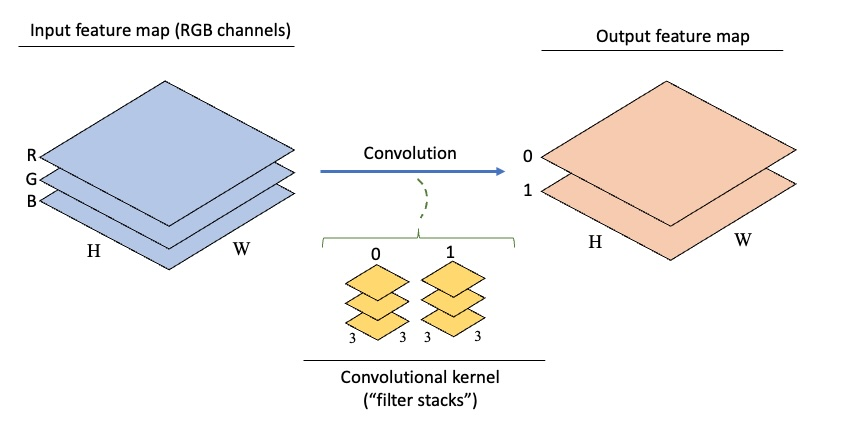

In this example, the input image has three channels, so each output feature layer is produced by a stack of three 3x3 filters, one for each input channel. Because we want to produce two output feature layers, the kernel contains two such filter stacks.

Putting this together, the full kernel has shape:

(2, 3, 3, 3)

= 18 weight values, each of which contributes to how the input channels are combined to form the output features.

To stick with familiar operations in the following code block, the first stack will be a blurring operation across three channels and the second will be a sharpening operation across three channels.

In [ ]:
# Start with 2D tensors to build from:
blur2d = torch.tensor([[1/9., 1/9., 1/9.],
                       [1/9., 1/9., 1/9.],
                       [1/9., 1/9., 1/9.]], dtype=torch.float32)

sharpen2d = torch.tensor([[ 0., -1.,  0.],
                          [-1.,  5., -1.],
                          [ 0., -1.,  0.]], dtype=torch.float32)

# Kernel tensor shape: (out_channels=2, in_channels=3, kH=3, kW=3)
kernel = torch.zeros((2, 3, 3, 3), dtype=torch.float32)

# The first filter stack is kernel[0,:,:,:].
# Make this first filter stack a blurring operation that is uniform across all input channels.
# (Since it performs the same operation on all three channels, the result will be
# the same as blurring a grayscale input).

# The second filter stack is kernel[1,:,:,:].
# Make this second filter stack an average of sharpening operations across all input channels.
# (Since it also performs the same operation on all three channels, the result will be
# the same as sharpening a grayscale input).

# Each stack is scaled by 1/3 so that their weights sum to one.
for c in range(3):
    kernel[0, c] = blur2d / 3.0       # blurred grayscale
    kernel[1, c] = sharpen2d / 3.0    # sharpened grayscale


#### Step 3: Define the convolutional layer and run


In [ ]:
# Define the convolutional layer "conv"
conv = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, bias=False, padding=1)

# Set the conv weights manually
conv.weight = nn.Parameter(kernel, requires_grad=False)

# Run the conv
convolution_result = conv(arr_tensor)  # (1, 2, H, W)


#### Step 4: Plot the result


In [ ]:
# Separate the input feature layers
R = arr_tensor[0, 0].detach().cpu()
G = arr_tensor[0, 1].detach().cpu()
B = arr_tensor[0, 2].detach().cpu()

# Separate the output feature layers
blur_gray  = convolution_result[0, 0].detach().cpu()
sharp_gray = convolution_result[0, 1].detach().cpu()

fig = plt.figure(figsize=(12, 7))

# Top row: RGB channels
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax3 = plt.subplot2grid((2, 3), (0, 2))

ax1.imshow(R, cmap="Reds")
ax1.set_title("Input 0: R channel")
ax1.axis("off")

ax2.imshow(G, cmap="Greens")
ax2.set_title("Input 1: G channel")
ax2.axis("off")

ax3.imshow(B, cmap="Blues")
ax3.set_title("Input 2: B channel")
ax3.axis("off")

# Bottom row: 2 output feature layers
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=1)
ax5 = plt.subplot2grid((2, 3), (1, 1), colspan=1)

ax4.imshow(blur_gray, cmap="gray")
ax4.set_title("Output 0: Blurred grayscale")
ax4.axis("off")

ax5.imshow(sharp_gray, cmap="gray")
ax5.set_title("Output 1: Sharpened grayscale")
ax5.axis("off")

plt.tight_layout()
plt.show()

print(f"{convolution_result.shape=}")

**Exercise:** Add a third filter stack to the colvolutional kernel. Build this from a 2D Laplacian filter ([[0,-1,0],[-1,4,-1],[0,-1,0]]), which is a common edge detector.